In [1]:
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.drivers import PySCFDriver


print("=" * 60)
print("VQE for LiH Molecule on simulator")
print("=" * 60)

# ---- Step 1: Generate N2 Hamiltonian ----
print("\n[1/5] Generating N2 Hamiltonian...")
driver = PySCFDriver(atom='Li 0 0 0; H 0 0 1.6', basis='sto3g')
problem = driver.run()
mapper = JordanWignerMapper()
hamiltonian = mapper.map(problem.hamiltonian.second_q_op())

print(f"  ✓ Number of qubits: {hamiltonian.num_qubits}")
print(f"  ✓ Number of Pauli terms: {len(hamiltonian)}")

VQE for LiH Molecule on simulator

[1/5] Generating N2 Hamiltonian...
  ✓ Number of qubits: 12
  ✓ Number of Pauli terms: 631


In [2]:
from scipy.sparse.linalg import eigsh

# Sparse reprezentace
hamiltonian_sparse = hamiltonian.to_matrix(sparse=True)

# Najdi nejnižší vlastní hodnotu
eigenvalues, eigenvectors = eigsh(hamiltonian_sparse, k=1, which='SA')
ground_state_energy = eigenvalues[0]

print(f"Ground state energy: {ground_state_energy} Ha")
print(f"Ground state vector shape: {eigenvectors.shape}")

Ground state energy: -8.87453164935849 Ha
Ground state vector shape: (4096, 1)


In [3]:
problem.nuclear_repulsion_energy

np.float64(0.992207270475)

In [4]:
expected_energy = ground_state_energy + problem.nuclear_repulsion_energy
print(f"Expected total energy (including nuclear repulsion): {expected_energy} Ha")

Expected total energy (including nuclear repulsion): -7.88232437888349 Ha


This circuit has  24 parameters


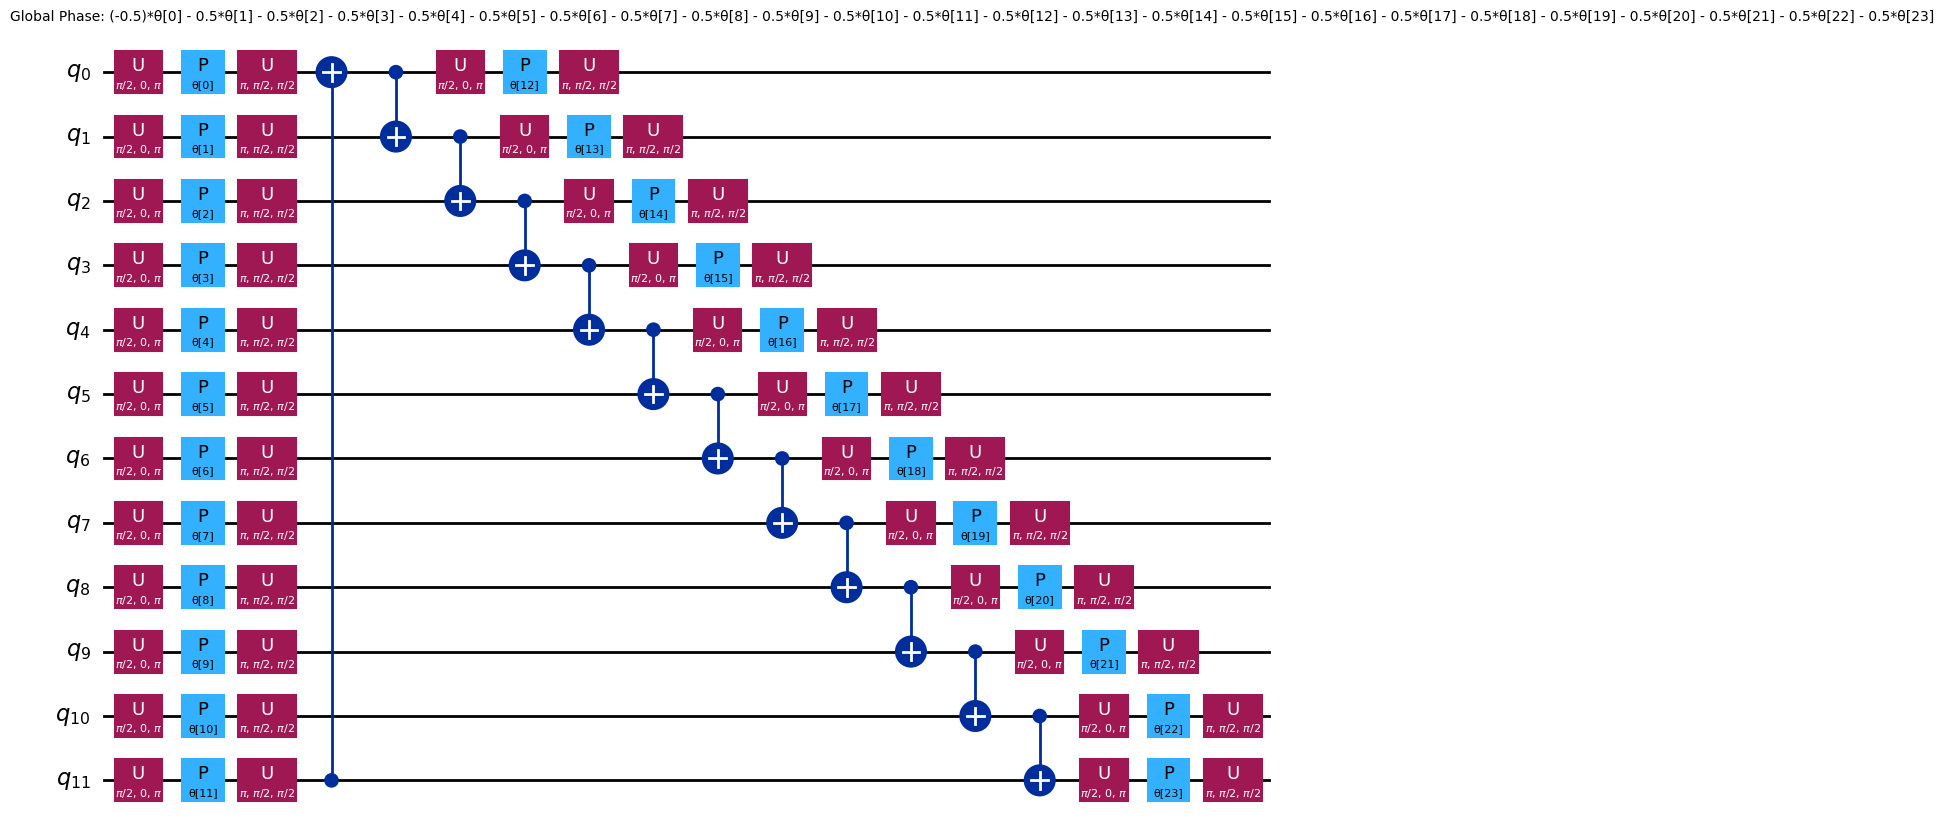

In [11]:
# Pre-defined ansatz circuit and operator class for Hamiltonian
from qiskit.circuit.library import efficient_su2
 
# Note that it is more common to place initial 'h' gates outside the ansatz. Here we specifically wanted this layer structure.
ansatz = efficient_su2(
    hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], entanglement="circular", reps=1
)
num_params = ansatz.num_parameters
print("This circuit has ", num_params, "parameters")
 
ansatz.decompose().draw("mpl", style="iqp")

In [12]:
from scipy.optimize import minimize
import numpy as np

import sys, os

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, ".."))
if project_root not in sys.path:
    sys.path.append(project_root)


from methods.methods import cost_function


iterations = [0]
file_name = "lih-one-rep.csv"
initial_params = np.zeros(ansatz.num_parameters)

print("Optimizing parameters...")
result = minimize(
    fun=cost_function, 
    x0=initial_params, 
    args=(problem, hamiltonian, ansatz, file_name, iterations),
    method='COBYLA', 
    options={"maxiter": 10_000}
)

print("-" * 30)
print(f"Optimized energy: {result.fun:.6f} Ha")
print(f"Expected:         {expected_energy} Ha")


Optimizing parameters...
Iteration 1: Evaluating cost function...
  Energy: -0.441463 Ha
Iteration 2: Evaluating cost function...
  Energy: -0.619131 Ha
Iteration 3: Evaluating cost function...
  Energy: -0.972832 Ha
Iteration 4: Evaluating cost function...
  Energy: -1.506233 Ha
Iteration 5: Evaluating cost function...
  Energy: -2.008645 Ha
Iteration 6: Evaluating cost function...
  Energy: -2.485908 Ha
Iteration 7: Evaluating cost function...
  Energy: -3.027749 Ha
Iteration 8: Evaluating cost function...
  Energy: -2.984734 Ha
Iteration 9: Evaluating cost function...
  Energy: -2.962735 Ha
Iteration 10: Evaluating cost function...
  Energy: -3.463791 Ha
Iteration 11: Evaluating cost function...
  Energy: -3.827572 Ha
Iteration 12: Evaluating cost function...
  Energy: -3.795343 Ha
Iteration 13: Evaluating cost function...
  Energy: -3.871125 Ha
Iteration 14: Evaluating cost function...
  Energy: -3.867237 Ha
Iteration 15: Evaluating cost function...
  Energy: -3.872076 Ha
Iteration

In [ ]:
from methods.methods import compute_error
print(f"Error: {compute_error(result.fun, expected=expected_energy):.2f}%")

Error: 2.32%


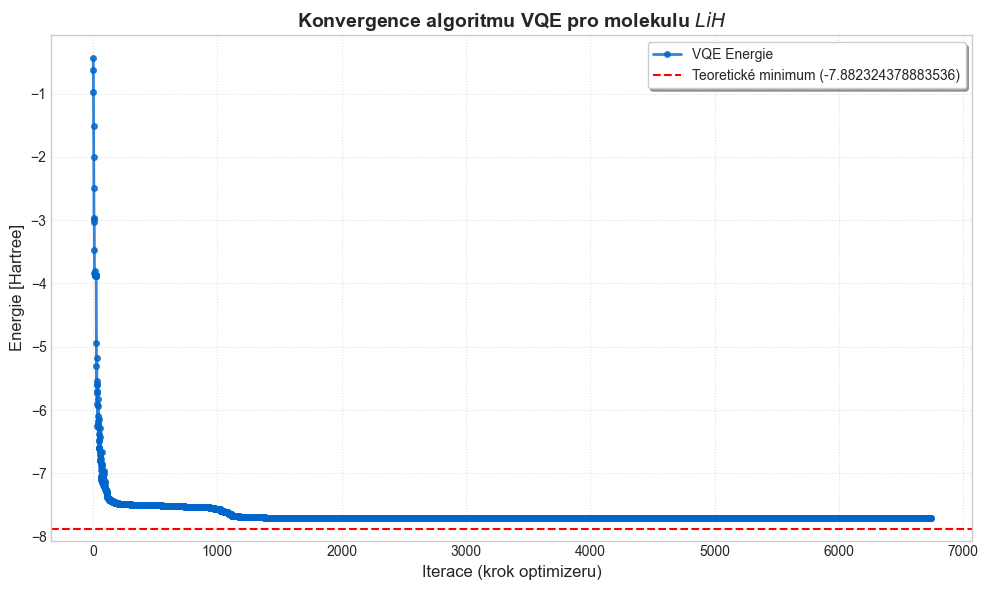

In [15]:
from methods.methods import plot_convergence
plot_convergence(file_name, "LiH", expected_energy)

This circuit has  48 parameters


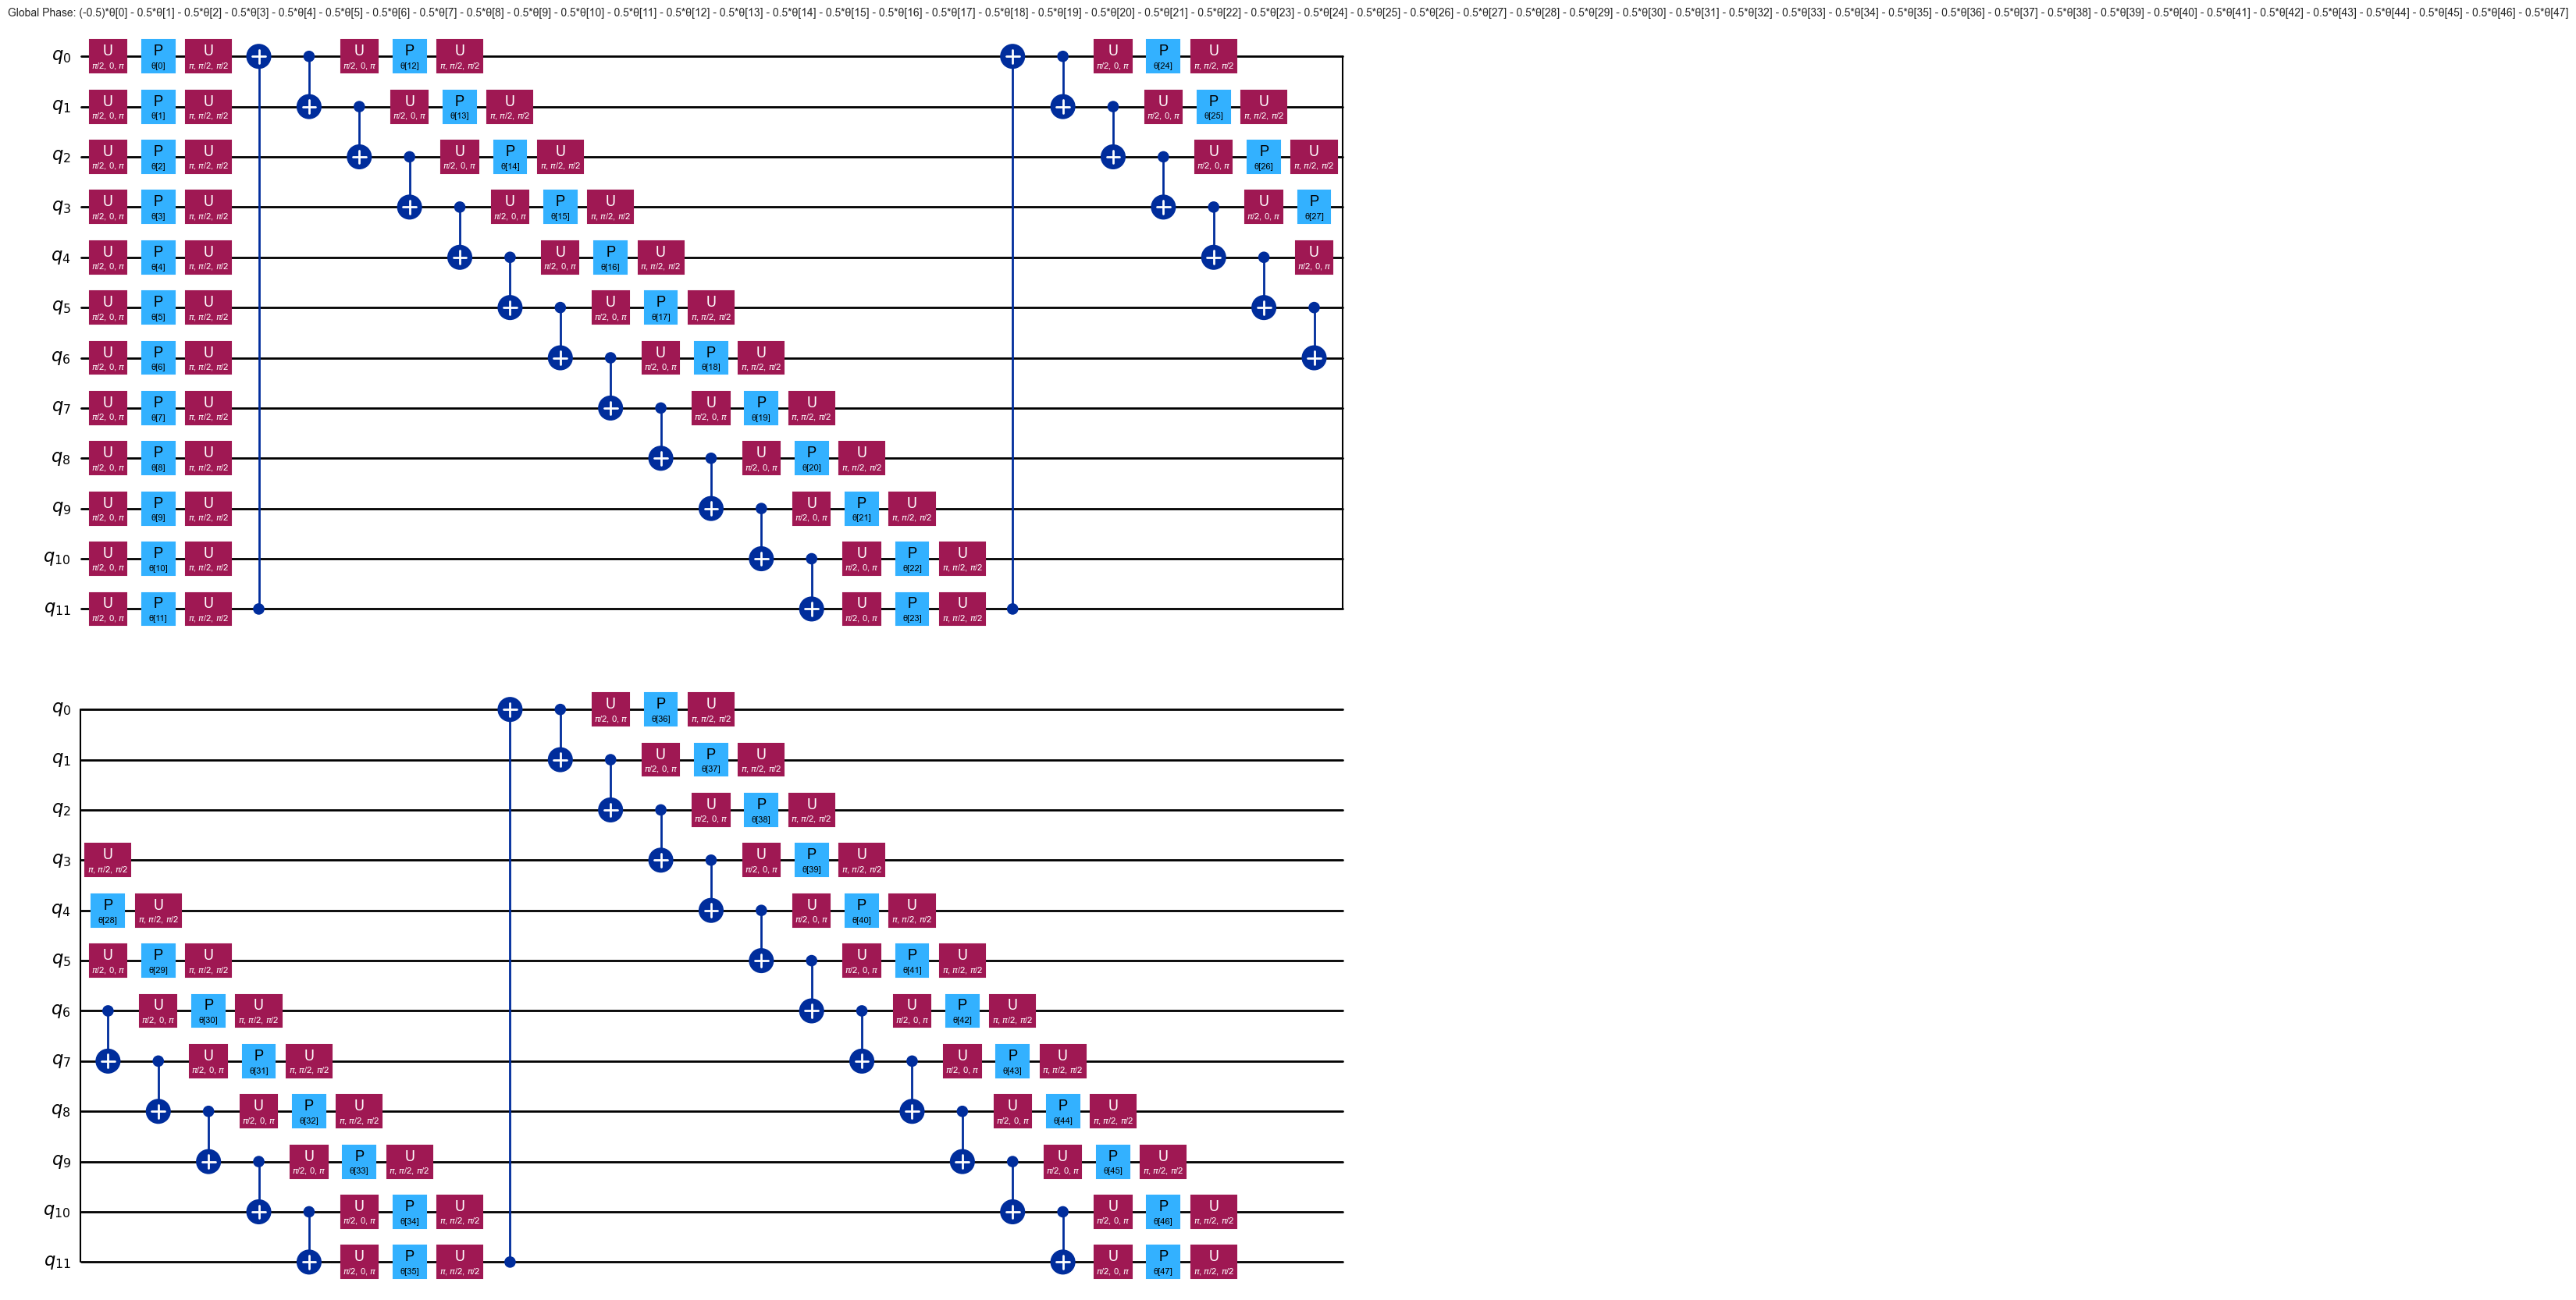

In [16]:
# Pre-defined ansatz circuit and operator class for Hamiltonian
from qiskit.circuit.library import efficient_su2
 
# Note that it is more common to place initial 'h' gates outside the ansatz. Here we specifically wanted this layer structure.
ansatz = efficient_su2(
    hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], entanglement="circular", reps=3
)
num_params = ansatz.num_parameters
print("This circuit has ", num_params, "parameters")
 
ansatz.decompose().draw("mpl", style="iqp")

In [17]:
iterations = [0]
file_name = "lih-three-rep.csv"
initial_params = np.zeros(ansatz.num_parameters)

print("Optimizing parameters...")
result = minimize(
    fun=cost_function, 
    x0=initial_params, 
    args=(problem, hamiltonian, ansatz, file_name, iterations),
    method='COBYLA', 
    options={"maxiter": 10_000}
)

print("-" * 30)
print(f"Optimized energy: {result.fun:.6f} Ha")
print(f"Expected:         {expected_energy} Ha")

Optimizing parameters...
Iteration 1: Evaluating cost function...
  Energy: -1.471209 Ha
Iteration 2: Evaluating cost function...
  Energy: -1.123574 Ha
Iteration 3: Evaluating cost function...
  Energy: -2.161550 Ha
Iteration 4: Evaluating cost function...
  Energy: -2.655496 Ha
Iteration 5: Evaluating cost function...
  Energy: -2.821085 Ha
Iteration 6: Evaluating cost function...
  Energy: -2.856752 Ha
Iteration 7: Evaluating cost function...
  Energy: -2.853309 Ha
Iteration 8: Evaluating cost function...
  Energy: -2.749143 Ha
Iteration 9: Evaluating cost function...
  Energy: -3.352884 Ha
Iteration 10: Evaluating cost function...
  Energy: -3.710992 Ha
Iteration 11: Evaluating cost function...
  Energy: -3.710149 Ha
Iteration 12: Evaluating cost function...
  Energy: -3.724206 Ha
Iteration 13: Evaluating cost function...
  Energy: -3.701830 Ha
Iteration 14: Evaluating cost function...
  Energy: -3.724206 Ha
Iteration 15: Evaluating cost function...
  Energy: -3.711578 Ha
Iteration

In [18]:
from methods.methods import compute_error
print(f"Error: {compute_error(result.fun, expected_energy):.2f}%")

Error: 2.03%


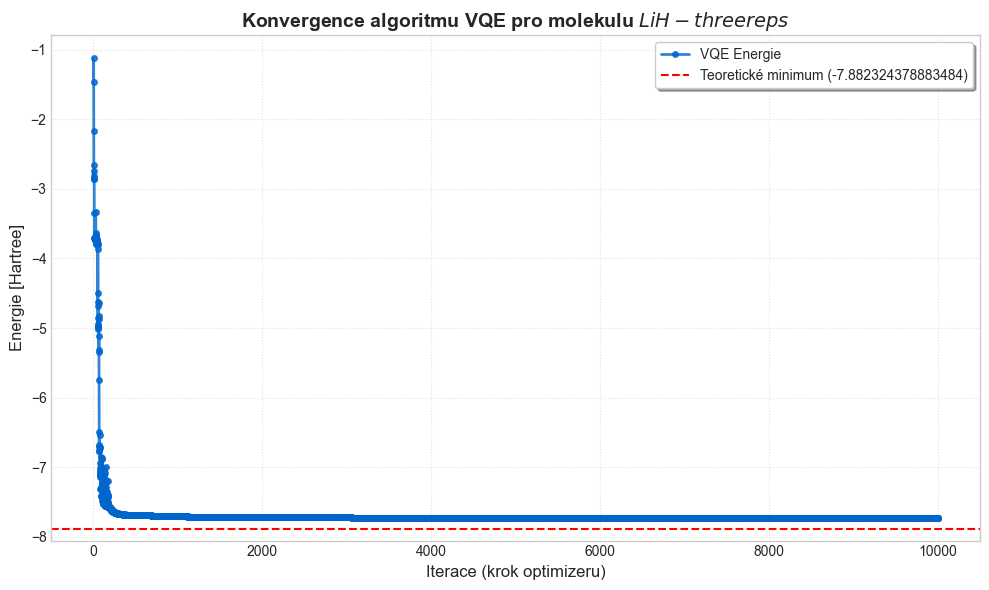

In [ ]:
from methods.methods import plot_convergence
plot_convergence("lih-three-rep.csv", "LiH - three reps", expected_energy)

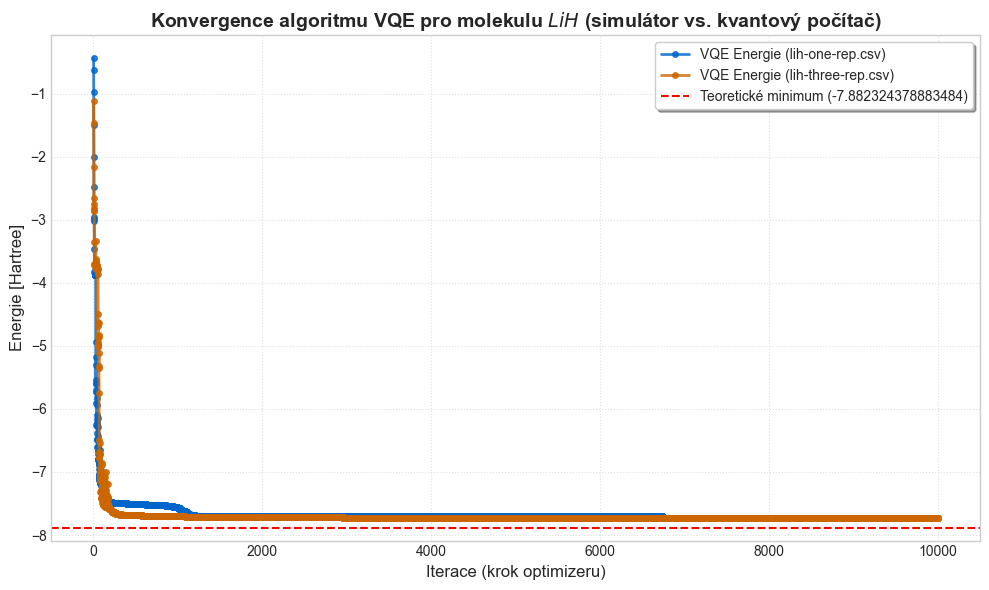

In [5]:
import sys, os

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from methods.methods import plot_convergence_comparison
plot_convergence_comparison(
    "lih-one-rep.csv", "lih-three-rep.csv",
    "LiH",
    expected_energy
)   

Expectation values for pub 0: -0.19440027723732806


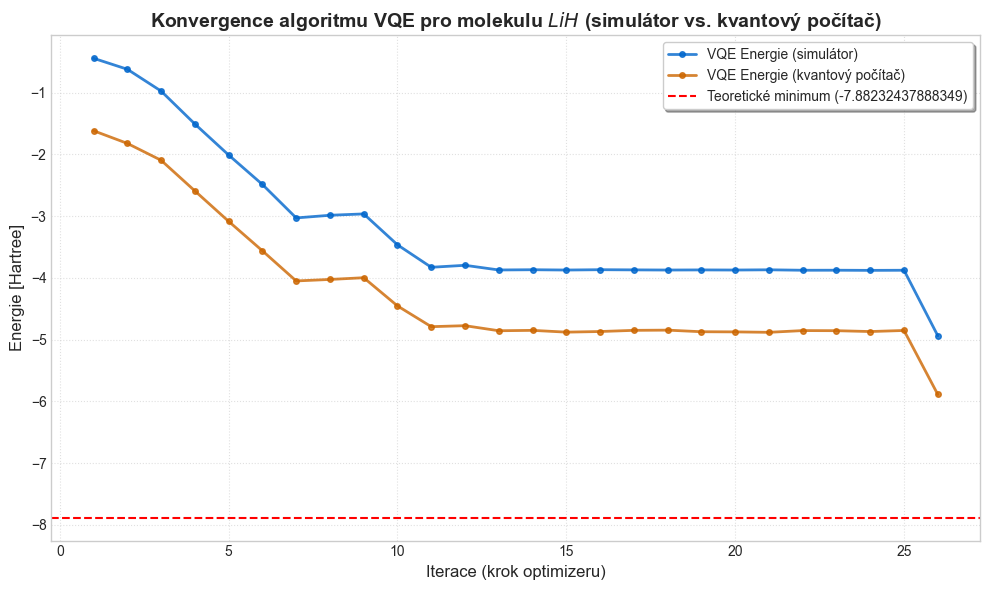

In [5]:
import sys, os

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, ".."))
if project_root not in sys.path:
    sys.path.append(project_root)
from methods.methods import plot_convergence_simulator_qc
plot_convergence_simulator_qc(
    "lih-one-rep.csv", "/Users/ema/Documents/Python/quantum/ntc/VQE_for_el_H/data-from-qc/LiH-data/LiH_data_from_qc_.csv",
    "LiH",
    expected_energy
)

In [12]:
hf_benchmark = problem.reference_energy
print(f"Hartree-Fock benchmark energy: {hf_benchmark:.6f} Ha")


Hartree-Fock benchmark energy: -7.861865 Ha
